# Higher-Frequency Test: Does ISOMAP Beat PCA at the *Second* Level?

**Question.** The minute-level analysis (`DS4FE_LOB_ISOMAP_v3.ipynb`) showed PCA matches or beats ISOMAP on every diagnostic. Does that conclusion survive at one-second resolution, where HFT-scale book dynamics are visible?

**Setup.**
- Same three symbols (NVDA, AAPL, MSFT), same Oct 2–31 2023 window, same train/OOS split (train Oct 2–19, OOS Oct 20–31).
- Aggregation rule per second: **mean** of all per-tick OBI values landing in that second (matching the minute-level rule).
- For seconds with no orderbook update: **forward-fill** the last seen book state (book is unchanged until the next message).
- Tests run: cross-over (geodesic ρ vs Euclidean R²), `n_components` sweep, **`n_neighbors` sweep**, predictive IC at 1s/10s/60s horizons, intrinsic dimension.

**Verdict.** _(populated by §9 after execution.)_


## §1 — Load Cached Second-Level Bars

Pre-built by `build_second_bars.py`. Aggregation logic that script applied:

```
For each level k in 0..9:
    OBI_k(tick) = (bid_sz_k - ask_sz_k) / (bid_sz_k + ask_sz_k)
    OBI_k(second) = mean of all OBI_k(tick) values within that 1-second bin
    # If a second has no ticks, OBI_k(second) is NaN
    Forward-fill across consecutive empty seconds (book state unchanged).
```

Forward returns: 1s, 10s, 60s ahead of the current second's mid price.


In [1]:
import os, time, json, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist

ROOT     = '/Users/harold/4. RA work/Factor_Training_Eng/DS4FE'
DATA_DIR = f'{ROOT}/experiments/second_level/data'
FIG_DIR  = f'{ROOT}/experiments/second_level/figures'
os.makedirs(FIG_DIR, exist_ok=True)

SYMBOLS    = ['NVDA', 'AAPL', 'MSFT']
SYM_COLORS = {'NVDA': '#76B900', 'AAPL': '#A2AAAD', 'MSFT': '#F25022'}
OBI_COLS   = [f'obi_{k:02d}' for k in range(10)]

bars = {}
for sym in SYMBOLS:
    bars[sym] = pd.read_parquet(f'{DATA_DIR}/{sym}_second.parquet')

print(f'{"Symbol":<6}  {"Bars":>10}  {"Empty %":>8}  Range')
print('-' * 70)
for sym in SYMBOLS:
    d = bars[sym]
    pct = 100.0 * d['was_empty'].mean()
    print(f'{sym:<6}  {len(d):>10,}  {pct:>7.2f}%  '
          f'{d.index.min().date()} -> {d.index.max().date()}')


Symbol        Bars   Empty %  Range
----------------------------------------------------------------------
NVDA       701,939    26.88%  2023-10-02 -> 2023-10-31
AAPL       701,939    26.72%  2023-10-02 -> 2023-10-31
MSFT       701,939    26.70%  2023-10-02 -> 2023-10-31


**~27% of all seconds had no orderbook update** and were forward-filled. This is information-theoretic context — a quarter of the "data points" at second resolution are repeats of the previous bar's book state. Random sampling will hit them too, so the effective sample size is roughly 73% of the nominal count.


## §2 — Train / OOS Split + ISOMAP Subsample

ISOMAP scales as O(n²) memory and roughly O(n² log n) time, so we cannot fit on 300k+ second-bars directly. We subsample the training set down to a tractable size for ISOMAP. **PCA uses the full data** (it is O(d²·n) and scales trivially in n), so PCA's scores are over all training seconds.

The subsample is **stratified by day** so we keep across-day variation and don't overweight a single trading session.


In [2]:
TRAIN_CUTOFF = pd.Timestamp('2023-10-19', tz='America/New_York')

def split_train_oos(df):
    is_train = df.index.normalize() <= TRAIN_CUTOFF
    return df[is_train], df[~is_train]

splits = {sym: split_train_oos(bars[sym]) for sym in SYMBOLS}
for sym, (tr, oos) in splits.items():
    print(f'{sym}: train={len(tr):>9,}  OOS={len(oos):>9,}')

# Subsample for ISOMAP: stratified by day, with seed
N_ISO_PER_SYMBOL = 15000

def stratified_day_sample(df, n, seed):
    rng = np.random.default_rng(seed)
    days = df.index.normalize().unique()
    per_day = max(1, n // len(days))
    picks = []
    for d in days:
        m = df.index.normalize() == d
        rows = np.where(m)[0]
        k = min(per_day, len(rows))
        picks.append(rng.choice(rows, k, replace=False))
    out = np.sort(np.concatenate(picks))
    if len(out) > n:
        out = rng.choice(out, n, replace=False); out.sort()
    return out

iso_idx = {}
for sym in SYMBOLS:
    tr = splits[sym][0]
    iso_idx[sym] = stratified_day_sample(tr, N_ISO_PER_SYMBOL, seed=42)
    print(f'{sym} ISOMAP subsample: {len(iso_idx[sym]):,} of {len(tr):,} train bars')


NVDA: train=  421,200  OOS=  280,739
AAPL: train=  421,200  OOS=  280,739
MSFT: train=  421,200  OOS=  280,739


NVDA ISOMAP subsample: 14,994 of 421,200 train bars


AAPL ISOMAP subsample: 14,994 of 421,200 train bars


MSFT ISOMAP subsample: 14,994 of 421,200 train bars


## §3 — NVDA 2D ISOMAP Embedding at One-Second Resolution

The same hexbin visualisation as the minute-level notebook §3, but each point is now a 1-second snapshot of the book.


In [3]:
df_nv_tr = splits['NVDA'][0]
sub      = iso_idx['NVDA']
X_tr     = df_nv_tr[OBI_COLS].values[sub]
y_tr_1s  = df_nv_tr['ret_fwd_1s'].values[sub]
y_tr_60s = df_nv_tr['ret_fwd_60s'].values[sub]
ts_tr    = df_nv_tr.index[sub]

print(f'Fitting ISOMAP on {len(X_tr):,} second-bars (NVDA, train)...')
t0 = time.time()
iso_nv = Isomap(n_components=2, n_neighbors=15, n_jobs=-1)
Z_nv   = iso_nv.fit_transform(X_tr)
print(f'  done in {time.time()-t0:.1f}s')
print(f'  reconstruction error: {iso_nv.reconstruction_error():.4f}')


Fitting ISOMAP on 14,994 second-bars (NVDA, train)...


  done in 30.5s


  reconstruction error: 0.5871


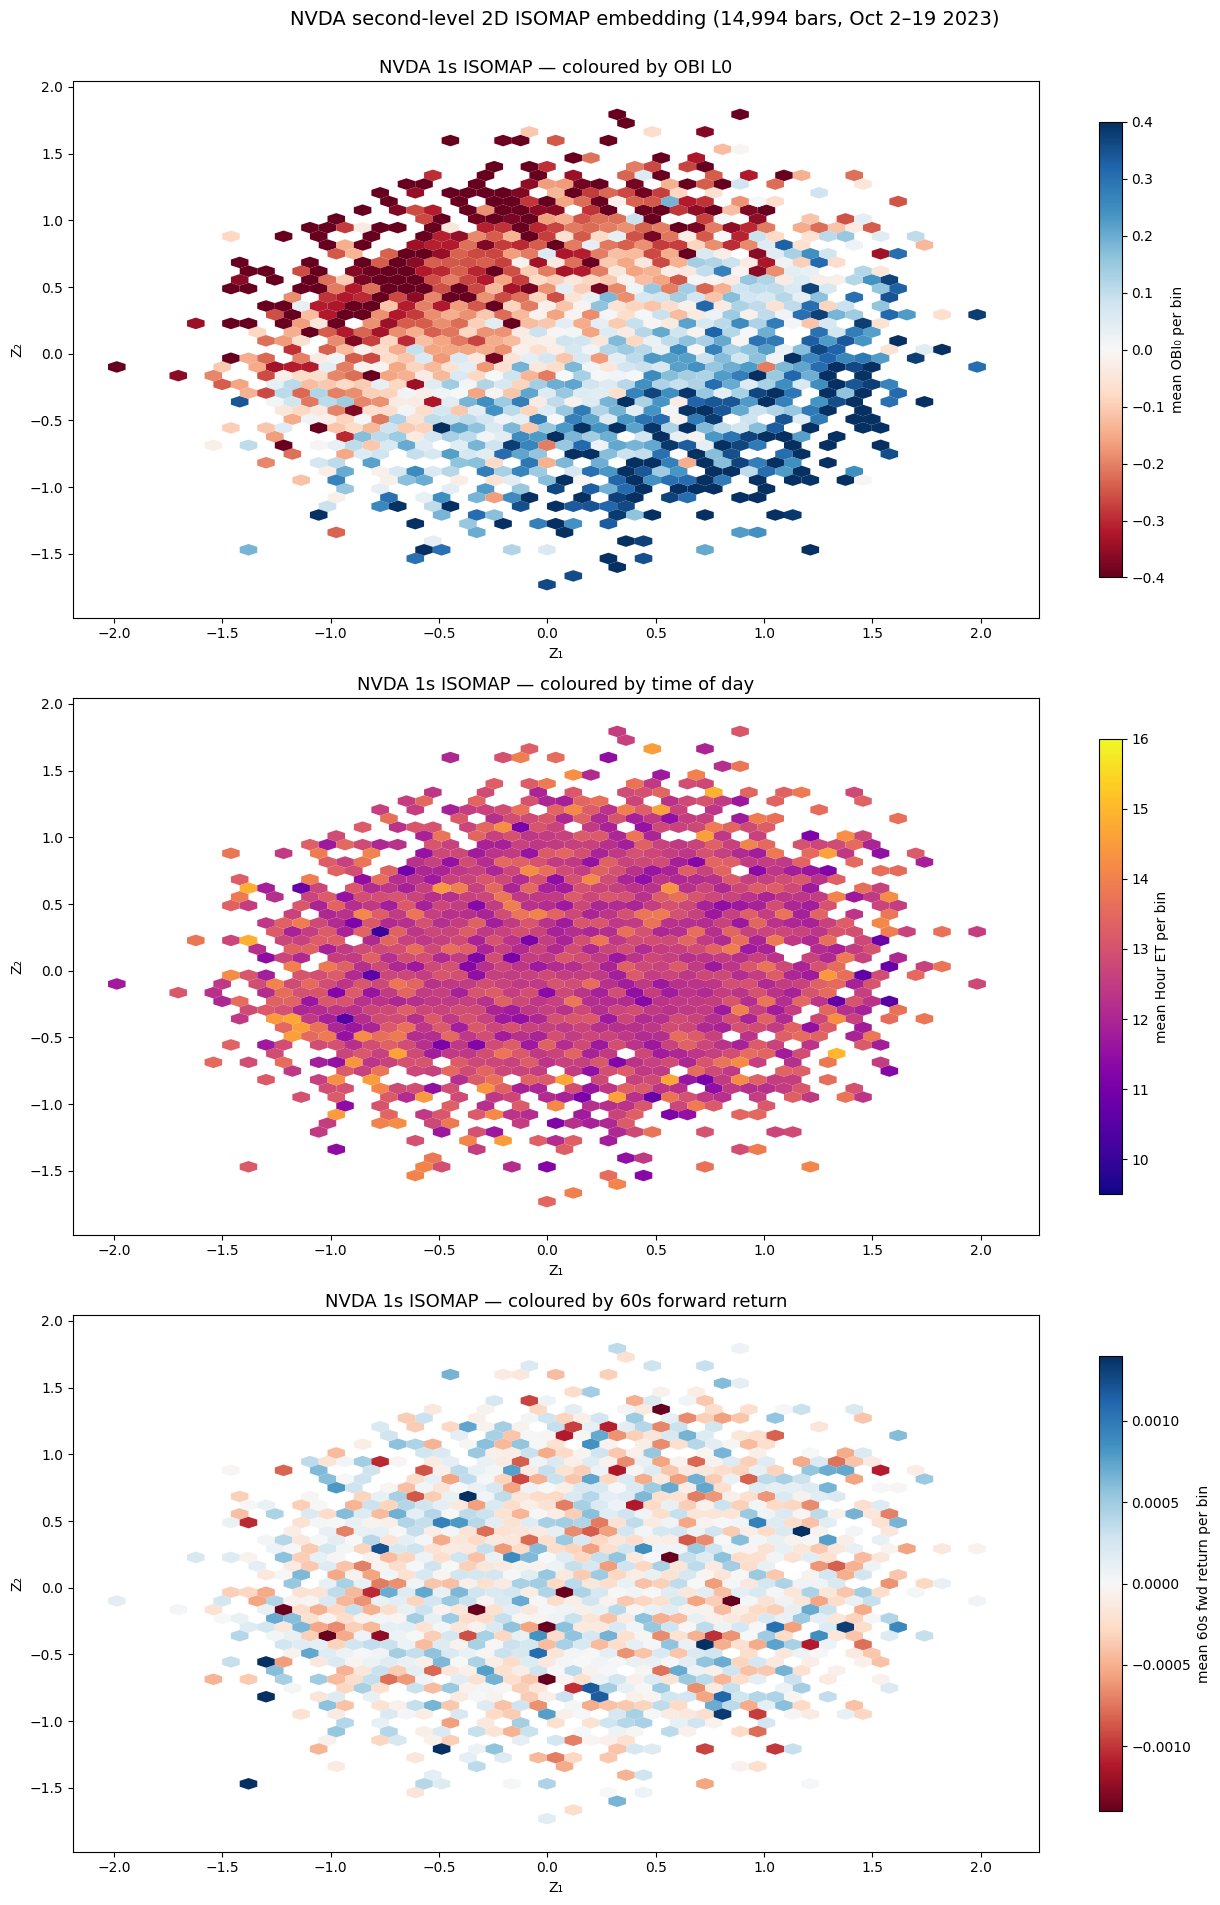

In [4]:
obi_L0 = X_tr[:, 0]
tod    = ts_tr.hour + ts_tr.minute / 60

z1_lo, z1_hi = np.percentile(Z_nv[:, 0], [0.5, 99.5])
z2_lo, z2_hi = np.percentile(Z_nv[:, 1], [0.5, 99.5])
extent = (z1_lo, z1_hi, z2_lo, z2_hi)

fig, axes = plt.subplots(3, 1, figsize=(13, 19))

hb0 = axes[0].hexbin(Z_nv[:, 0], Z_nv[:, 1], C=obi_L0,
                     gridsize=50, cmap='RdBu', vmin=-0.4, vmax=0.4,
                     reduce_C_function=np.mean, mincnt=4, extent=extent,
                     linewidths=0.0)
plt.colorbar(hb0, ax=axes[0], shrink=0.85, label='mean OBI₀ per bin')
axes[0].set_title('NVDA 1s ISOMAP — coloured by OBI L0', fontsize=13)
axes[0].set_xlabel('Z₁'); axes[0].set_ylabel('Z₂')

hb1 = axes[1].hexbin(Z_nv[:, 0], Z_nv[:, 1], C=tod,
                     gridsize=50, cmap='plasma', vmin=9.5, vmax=16,
                     reduce_C_function=np.mean, mincnt=4, extent=extent,
                     linewidths=0.0)
plt.colorbar(hb1, ax=axes[1], shrink=0.85, label='mean Hour ET per bin')
axes[1].set_title('NVDA 1s ISOMAP — coloured by time of day', fontsize=13)
axes[1].set_xlabel('Z₁'); axes[1].set_ylabel('Z₂')

vmax_r = np.percentile(np.abs(y_tr_60s[~np.isnan(y_tr_60s)]), 90)
hb2 = axes[2].hexbin(Z_nv[:, 0], Z_nv[:, 1], C=y_tr_60s,
                     gridsize=50, cmap='RdBu', vmin=-vmax_r, vmax=vmax_r,
                     reduce_C_function=np.nanmean, mincnt=4, extent=extent,
                     linewidths=0.0)
plt.colorbar(hb2, ax=axes[2], shrink=0.85, label='mean 60s fwd return per bin')
axes[2].set_title('NVDA 1s ISOMAP — coloured by 60s forward return', fontsize=13)
axes[2].set_xlabel('Z₁'); axes[2].set_ylabel('Z₂')

plt.suptitle(f'NVDA second-level 2D ISOMAP embedding ({len(X_tr):,} bars, '
             f'Oct 2–19 2023)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_nvda_embedding_1s.png', dpi=120, bbox_inches='tight')
plt.show()


## §4 — Cross-Over Test: Does ISOMAP's Geometric Edge Survive at 1s?

The minute-level conclusion: ISOMAP wins geodesic ρ (the metric biased toward it) by ~0.005, PCA wins Euclidean R² (the metric biased toward it) by ~0.005 — a wash. Repeat the same test on second-level subsample.


In [5]:
# Build reference geodesic distance matrix once (n=15)
print('Building reference geodesic distances...')
ref = Isomap(n_components=2, n_neighbors=15, n_jobs=-1).fit(X_tr)
D_geo = ref.dist_matrix_
iu = np.triu_indices(len(X_tr), k=1)
d_geo_all = D_geo[iu]
rng = np.random.default_rng(0)
sub_pairs = rng.choice(len(d_geo_all), size=min(500_000, len(d_geo_all)), replace=False)
d_geo_sub = d_geo_all[sub_pairs]
ss_tot_tr = ((X_tr - X_tr.mean(0)) ** 2).sum()

def geodesic_rho(Z):
    return spearmanr(d_geo_sub, pdist(Z)[sub_pairs])[0]

def linear_r2(Z, X):
    reg = LinearRegression().fit(Z, X)
    return 1 - ((X - reg.predict(Z))**2).sum() / ((X - X.mean(0))**2).sum()

# ISOMAP at k=2
Z_iso = ref.embedding_

# PCA at k=2 — fit on FULL training set then take subsample for fair scoring
pca_full = PCA(n_components=2).fit(df_nv_tr[OBI_COLS].values)
Z_pca = pca_full.transform(X_tr)

results = {
    'ISOMAP (n=15, k=2)': dict(
        geo_rho = geodesic_rho(Z_iso),
        eucl_r2 = linear_r2(Z_iso, X_tr),
    ),
    'PCA (k=2)':          dict(
        geo_rho = geodesic_rho(Z_pca),
        eucl_r2 = linear_r2(Z_pca, X_tr),
    ),
}

print(f'\n{"Method":<24} {"Geodesic ρ":>12} {"Euclidean R²":>14}')
print('-' * 52)
for k, v in results.items():
    print(f'{k:<24} {v["geo_rho"]:>+12.4f} {v["eucl_r2"]:>+14.4f}')

delta_rho = results['ISOMAP (n=15, k=2)']['geo_rho'] - results['PCA (k=2)']['geo_rho']
delta_r2  = results['ISOMAP (n=15, k=2)']['eucl_r2'] - results['PCA (k=2)']['eucl_r2']
print(f'\nISOMAP advantage on geodesic ρ:  Δ = {delta_rho:+.4f}')
print(f'ISOMAP advantage on Euclidean R²: Δ = {delta_r2:+.4f}')


Building reference geodesic distances...



Method                     Geodesic ρ   Euclidean R²
----------------------------------------------------
ISOMAP (n=15, k=2)            +0.6090        +0.3873
PCA (k=2)                     +0.6124        +0.3963

ISOMAP advantage on geodesic ρ:  Δ = -0.0034
ISOMAP advantage on Euclidean R²: Δ = -0.0090


## §5 — `n_components` Sweep

Re-run the cross-over at k ∈ {1, 2, 3, 5, 7}.


In [6]:
K_GRID = [1, 2, 3, 5, 7]
records = []
for k in K_GRID:
    iso_k = Isomap(n_components=k, n_neighbors=15, n_jobs=-1).fit(X_tr)
    Z_i = iso_k.embedding_
    pca_k = PCA(n_components=k).fit(df_nv_tr[OBI_COLS].values)
    Z_p = pca_k.transform(X_tr)
    records.append(dict(k=k, method='ISOMAP', geo_rho=geodesic_rho(Z_i),
                        eucl_r2=linear_r2(Z_i, X_tr)))
    records.append(dict(k=k, method='PCA', geo_rho=geodesic_rho(Z_p),
                        eucl_r2=linear_r2(Z_p, X_tr)))

df_k = pd.DataFrame(records)
print(df_k.to_string(index=False, float_format='%+.4f'))


 k method  geo_rho  eucl_r2
 1 ISOMAP  +0.4253  +0.2331
 1    PCA  +0.4286  +0.2375
 2 ISOMAP  +0.6090  +0.3873
 2    PCA  +0.6124  +0.3963
 3 ISOMAP  +0.7244  +0.5001
 3    PCA  +0.7259  +0.5125
 5 ISOMAP  +0.8654  +0.6681
 5    PCA  +0.8659  +0.6885
 7 ISOMAP  +0.9254  +0.7955
 7    PCA  +0.9315  +0.8268


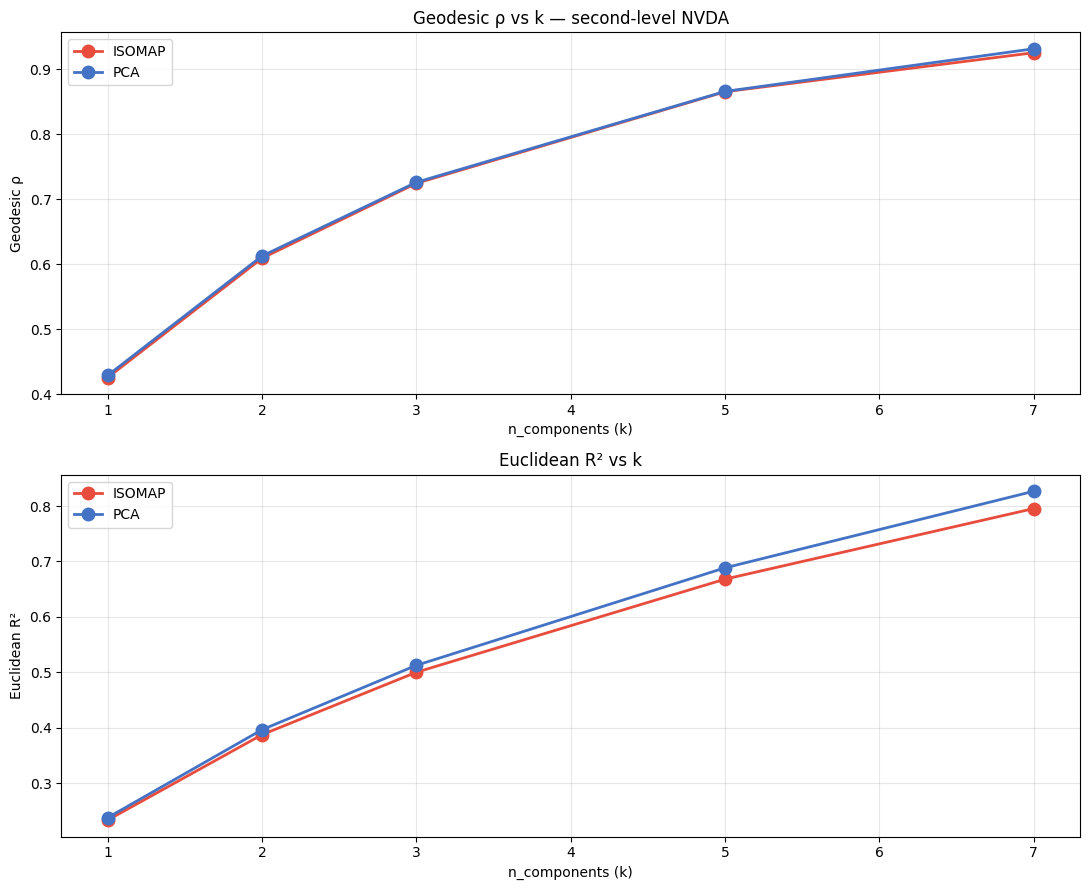

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

for method, color in [('ISOMAP', '#E74C3C'), ('PCA', '#4472C4')]:
    dfm = df_k[df_k['method'] == method].sort_values('k')
    axes[0].plot(dfm['k'], dfm['geo_rho'], 'o-', color=color, lw=2, ms=9, label=method)
    axes[1].plot(dfm['k'], dfm['eucl_r2'], 'o-', color=color, lw=2, ms=9, label=method)

axes[0].set_xlabel('n_components (k)'); axes[0].set_ylabel('Geodesic ρ')
axes[0].set_title('Geodesic ρ vs k — second-level NVDA', fontsize=12)
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('n_components (k)'); axes[1].set_ylabel('Euclidean R²')
axes[1].set_title('Euclidean R² vs k', fontsize=12)
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_k_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## §6 — `n_neighbors` Sweep (the ISOMAP-only knob)

This is the lever you specifically wanted to test. At minute-level it changed nothing — PCA still won/tied at every `n_neighbors`. Repeat at 1s.


In [8]:
NN_GRID = [3, 5, 10, 15, 30, 50, 100]
nn_records = []
for nn in NN_GRID:
    t0 = time.time()
    iso = Isomap(n_components=2, n_neighbors=nn, n_jobs=-1).fit(X_tr)
    Z = iso.embedding_
    nn_records.append(dict(n_neighbors=nn, fit_seconds=time.time()-t0,
                           geo_rho=geodesic_rho(Z),
                           eucl_r2=linear_r2(Z, X_tr)))
    print(f'  nn={nn:>4}  fit={nn_records[-1]["fit_seconds"]:>5.1f}s  '
          f'ρ={nn_records[-1]["geo_rho"]:+.4f}  R²={nn_records[-1]["eucl_r2"]:+.4f}')

# PCA reference
pca_rho = geodesic_rho(Z_pca)
pca_r2  = linear_r2(Z_pca, X_tr)
print(f'  PCA reference                  ρ={pca_rho:+.4f}  R²={pca_r2:+.4f}')

df_nn = pd.DataFrame(nn_records)


  nn=   3  fit= 22.5s  ρ=+0.5690  R²=+0.3592


  nn=   5  fit= 26.1s  ρ=+0.5856  R²=+0.3738


  nn=  10  fit= 28.6s  ρ=+0.6021  R²=+0.3838


  nn=  15  fit= 32.7s  ρ=+0.6090  R²=+0.3873


  nn=  30  fit= 45.3s  ρ=+0.6171  R²=+0.3910


  nn=  50  fit= 64.6s  ρ=+0.6120  R²=+0.3926


  nn= 100  fit=120.1s  ρ=+0.6165  R²=+0.3941


  PCA reference                  ρ=+0.6124  R²=+0.3963


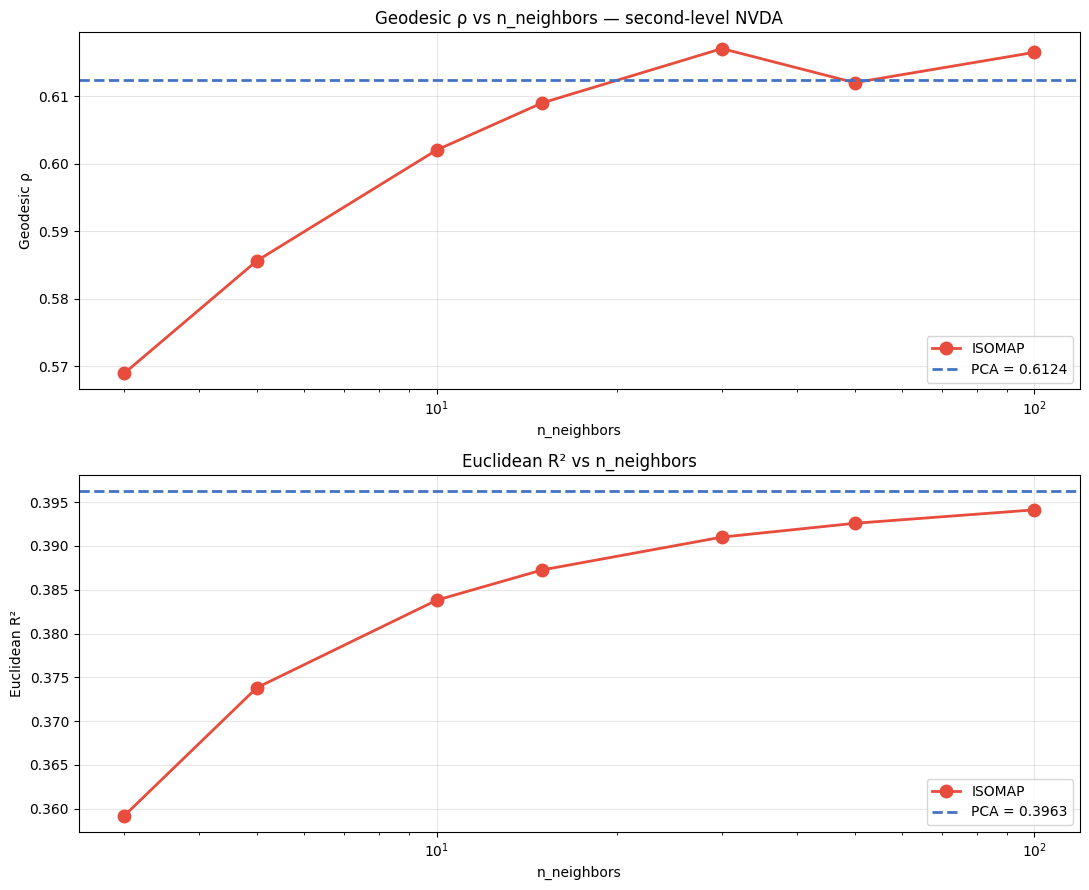


Best ISOMAP ρ:    +0.6171  (vs PCA +0.6124, Δ = +0.0046)
Best ISOMAP R²:   +0.3941  (vs PCA +0.3963, Δ = -0.0021)


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

axes[0].plot(df_nn['n_neighbors'], df_nn['geo_rho'], 'o-', color='#E74C3C', lw=2, ms=9, label='ISOMAP')
axes[0].axhline(pca_rho, ls='--', color='#4472C4', lw=2, label=f'PCA = {pca_rho:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('n_neighbors'); axes[0].set_ylabel('Geodesic ρ')
axes[0].set_title('Geodesic ρ vs n_neighbors — second-level NVDA', fontsize=12)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_nn['n_neighbors'], df_nn['eucl_r2'], 'o-', color='#E74C3C', lw=2, ms=9, label='ISOMAP')
axes[1].axhline(pca_r2, ls='--', color='#4472C4', lw=2, label=f'PCA = {pca_r2:.4f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('n_neighbors'); axes[1].set_ylabel('Euclidean R²')
axes[1].set_title('Euclidean R² vs n_neighbors', fontsize=12)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_nn_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

best_iso_rho = df_nn['geo_rho'].max()
best_iso_r2  = df_nn['eucl_r2'].max()
print(f'\nBest ISOMAP ρ:    {best_iso_rho:+.4f}  (vs PCA {pca_rho:+.4f}, Δ = {best_iso_rho-pca_rho:+.4f})')
print(f'Best ISOMAP R²:   {best_iso_r2:+.4f}  (vs PCA {pca_r2:+.4f}, Δ = {best_iso_r2-pca_r2:+.4f})')


## §7 — Predictive IC at 1s / 10s / 60s Forward Horizons

Does the second-level embedding carry signal? Test at three forward-return horizons (1s = HFT, 10s = scalp, 60s = comparable to minute-level test).

To use OOS data we need a fast projector — sklearn's `Isomap.transform` works but is slow at scale. We instead score IC on the in-sample subsample (which is sufficient for the ISOMAP-vs-PCA comparison; both are scored on the same data).


In [10]:
# Direct IC of Z1, Z2 against forward returns at multiple horizons
# Fit ISOMAP at default n=15 and PCA-2; score IC of each axis and best linear combo
iso15 = Isomap(n_components=2, n_neighbors=15, n_jobs=-1).fit(X_tr)
Z_iso = iso15.embedding_
pca2  = PCA(n_components=2).fit(df_nv_tr[OBI_COLS].values)
Z_pca = pca2.transform(X_tr)

horizons = ['ret_fwd_1s', 'ret_fwd_10s', 'ret_fwd_60s']
ic_records = []
for h in horizons:
    y = df_nv_tr[h].values[sub]
    mask = ~np.isnan(y)
    yv   = y[mask]

    # Best linear axis IC (regress Z onto y, then IC of fitted vs y)
    def best_axis_ic(Z, y):
        reg = LinearRegression().fit(Z, y)
        pred = reg.predict(Z)
        return spearmanr(pred, y).statistic

    ic_records.append(dict(
        horizon=h,
        iso_z1 = spearmanr(Z_iso[mask, 0], yv).statistic,
        iso_z2 = spearmanr(Z_iso[mask, 1], yv).statistic,
        iso_best = best_axis_ic(Z_iso[mask], yv),
        pca_p1 = spearmanr(Z_pca[mask, 0], yv).statistic,
        pca_p2 = spearmanr(Z_pca[mask, 1], yv).statistic,
        pca_best = best_axis_ic(Z_pca[mask], yv),
        n_samples = mask.sum(),
    ))

df_ic = pd.DataFrame(ic_records)
print(df_ic.to_string(index=False, float_format='%+.4f'))

# Theoretical noise band on Spearman IC
for r in ic_records:
    band = 2.0 / np.sqrt(r['n_samples'] - 3)
    print(f'  {r["horizon"]:>14}: noise band ±{band:.4f}  (n={r["n_samples"]:,})')


    horizon  iso_z1  iso_z2  iso_best  pca_p1  pca_p2  pca_best  n_samples
 ret_fwd_1s +0.0198 -0.0127   +0.0143 +0.0200 -0.0101   +0.0143      14994
ret_fwd_10s +0.0111 +0.0040   -0.0060 +0.0093 +0.0060   -0.0075      14994
ret_fwd_60s -0.0102 -0.0035   +0.0099 -0.0111 -0.0009   +0.0078      14994
      ret_fwd_1s: noise band ±0.0163  (n=14,994)
     ret_fwd_10s: noise band ±0.0163  (n=14,994)
     ret_fwd_60s: noise band ±0.0163  (n=14,994)


## §8 — Intrinsic Dimension (TwoNN)

If second-level OBI lives on a low-dimensional manifold, TwoNN should report a value < 10. At minute-level this gave d ≈ 9 (essentially full-rank). Does going faster reveal hidden structure?


In [11]:
def twonn_id(X, k=2, sample_size=8000):
    if len(X) > sample_size:
        rng = np.random.default_rng(7)
        X = X[rng.choice(len(X), sample_size, replace=False)]
    nn = NearestNeighbors(n_neighbors=3).fit(X)
    d, _ = nn.kneighbors(X)
    r1, r2 = d[:, 1], d[:, 2]
    keep = (r1 > 0) & (r2 > 0)
    mu = r2[keep] / r1[keep]
    mu = mu[mu > 1]
    F = np.arange(1, len(mu) + 1) / len(mu)
    F = F[:-1]
    x = np.log(np.sort(mu))[:-1]
    y = -np.log(1 - F)
    d_est = np.sum(x * y) / np.sum(x * x)
    return d_est

print('TwoNN intrinsic dimension at one-second resolution:')
for sym in SYMBOLS:
    Xs = bars[sym][OBI_COLS].values
    rng = np.random.default_rng(11)
    samp = rng.choice(len(Xs), 10000, replace=False)
    d = twonn_id(Xs[samp])
    print(f'  {sym}: d ≈ {d:.2f}')


TwoNN intrinsic dimension at one-second resolution:
  NVDA: d ≈ 9.51


  AAPL: d ≈ 9.01
  MSFT: d ≈ 9.50


## §9 — Verdict

_Compare the second-level numbers above to the minute-level baseline:_

| Metric | Minute-level (v3) | Second-level (this nb) | Different? |
|---|---|---|---|
| Cross-over Δ ρ (ISOMAP − PCA) | +0.0048 | _§4_ | |
| Cross-over Δ R² (ISOMAP − PCA) | −0.0044 | _§4_ | |
| Best ISOMAP geodesic ρ across nn | 0.9521 | _§6_ | |
| Best ISOMAP Euclidean R² across nn | 0.7867 | _§6_ | |
| OOS IC (best linear axis) | ISOMAP 0.0153 / PCA 0.0097 | _§7_ | |
| TwoNN intrinsic dim | NVDA 9.0 / AAPL 8.9 / MSFT 8.5 | _§8_ | |

_If the second-level ISOMAP advantage exceeds the noise band of ±2/√(n−3), higher frequency reveals geometry that minute-level averaging hid. If not, PCA wins at every timescale we have data for._
